In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score
)
import random
import optuna
import torch.optim as optim
import time
import torch.nn.functional as F
import os

In [2]:
df = pd.read_csv('./data/prepared_data_mill13.csv')
df['average_time'] = pd.to_datetime(df['average_time'], format='%Y-%m-%d %H:%M:%S')
df = df.sort_values(by='average_time')
df = df.reset_index(drop=True)
df

,Unnamed: 0,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg]
0,22,44.8055,2023-01-03,8:35÷8:50,53.9,5.2,22.45,57.47,2023-01-03 08:42:30,0.5747,0.7755,0.078660,156.522063
1,23,63.8130,2023-01-03,12:14÷12:19,42.5,3.0,20.46,64.03,2023-01-03 12:16:30,0.6403,0.7954,0.053364,230.719433
2,24,66.9386,2023-01-03,15:00÷15:06,48.8,3.3,33.59,48.60,2023-01-03 15:03:00,0.4860,0.6641,0.135403,90.929089
3,145,91.5623,2023-01-06,8:58÷9:10,45.0,3.3,32.08,42.55,2023-01-06 09:04:00,0.4255,0.6792,0.201339,61.150946
4,146,97.1414,2023-01-06,11:30÷11:37,49.1,4.2,17.93,66.95,2023-01-06 11:33:30,0.6695,0.8207,0.044909,274.157668
...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,167,36.9784,2023-12-09,10:45÷10:58,50.1,4.8,16.59,66.86,2023-12-09 10:51:30,0.6686,0.8341,0.045149,272.699554
173,168,46.2246,2023-12-09,11:40÷11:52,59.5,4.1,11.47,73.24,2023-12-09 11:46:00,0.7324,0.8853,0.030759,400.273036
174,169,54.3461,2023-12-09,15:20÷15:30,60.6,3.9,12.36,72.12,2023-12-09 15:25:00,0.7212,0.8764,0.032941,373.767084
175,170,55.2992,2023-12-09,16:20÷16:30,59.6,4.2,28.64,49.77,2023-12-09 16:25:00,0.4977,0.7136,0.125776,97.888850


In [3]:
df_periodic = pd.read_csv('./data/periodic_selections.csv')
df_periodic['average_time'] = pd.to_datetime(df_periodic['average_time'], format='%Y-%m-%d %H:%M:%S')
df_periodic = df_periodic.reset_index(drop=True)
df_periodic

,Unnamed: 0,Q_bauxite_[t/h],time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg]
0,22,44.8055,8:35÷8:50,53.9,5.2,22.45,57.47,2023-01-03 08:42:30,0.5747,0.7755,0.078660,156.522063
1,23,63.8130,12:14÷12:19,42.5,3.0,20.46,64.03,2023-01-03 12:16:30,0.6403,0.7954,0.053364,156.522063
2,24,66.9386,15:00÷15:06,48.8,3.3,33.59,48.60,2023-01-03 15:03:00,0.4860,0.6641,0.135403,156.522063
3,145,91.5623,8:58÷9:10,45.0,3.3,32.08,42.55,2023-01-06 09:04:00,0.4255,0.6792,0.201339,61.150946
4,146,97.1414,11:30÷11:37,49.1,4.2,17.93,66.95,2023-01-06 11:33:30,0.6695,0.8207,0.044909,61.150946
...,...,...,...,...,...,...,...,...,...,...,...,...
161,167,36.9784,10:45÷10:58,50.1,4.8,16.59,66.86,2023-12-09 10:51:30,0.6686,0.8341,0.045149,45.417568
162,168,46.2246,11:40÷11:52,59.5,4.1,11.47,73.24,2023-12-09 11:46:00,0.7324,0.8853,0.030759,45.417568
163,169,54.3461,15:20÷15:30,60.6,3.9,12.36,72.12,2023-12-09 15:25:00,0.7212,0.8764,0.032941,45.417568
164,170,55.2992,16:20÷16:30,59.6,4.2,28.64,49.77,2023-12-09 16:25:00,0.4977,0.7136,0.125776,45.417568


In [6]:
BAUXITE_DENSITY = 2800  # плотность боксита, кг/м3
INITIAL_BAUXITE = 7 # исходное количество боксита в мельнице, т

# Параметры для расчета объема пульпы в мельнице
FILL_RATE = 0.45  # доля заполнения мельницы
BALL_MASS = 60  # масса мелящих шаров, т
MILL_VOLUME = 36  # объем мельницы, м3
MILL_LENGTH = 4.5 # длина мельницы, м
STEEL_DENSITY = 7800  # плотность стали, кг/м3
BAUXITE_DENSITY = 2800  # плотность боксита, кг/м3
WATER_DENSITY = 1000 # плотность воды, кг/м3

# -- Для Розина-Раммлера --
D1 = 0.056 # диаметр сита, мм
D2 = 0.16 # диаметр сита, мм

# объём шаров, м3
BALL_VOLUME = BALL_MASS * 1000 / STEEL_DENSITY

# Объём пульпы (боксит+вода+раствор), м3
SLURRY_VOLUME = MILL_VOLUME * FILL_RATE - BALL_VOLUME

# Площадь сечения мельницы, м2
MILL_AREA =  MILL_VOLUME / MILL_LENGTH

# Площадь сечения пульпы, м2
F_SLURRY = SLURRY_VOLUME / MILL_LENGTH

# epsilon для вычисления скорости
EPS = 1-(BALL_VOLUME/MILL_VOLUME)

In [7]:
S_max = 500

In [8]:
import numpy as np

def mean_filter(data, window_size):
    kernel = np.ones(window_size) / window_size
    return np.convolve(data, kernel, mode='same')


df['Qsolid_[m3/h]'] = df['Q_bauxite_[t/h]'] * 0.9 * 1000 / BAUXITE_DENSITY 
df['Qliquid_[m3/h]'] = (df['Q_bauxite_[t/h]'] * 0.1 * 1000 / WATER_DENSITY) + df['Q_liquid_mill13_[m3/h]'] # Вычисление жидкой составляющей
df['V_[m/s]'] = EPS * (df['Qsolid_[m3/h]']+df['Qliquid_[m3/h]']) / (F_SLURRY * 3600)
df['residence_time_[s]'] = MILL_LENGTH / df['V_[m/s]']

# MEAN FILTER
df['mean_S_[m2/kg]'] = mean_filter(df['S_[m2/kg]'].to_numpy(), window_size=7)

df

,Unnamed: 0,Q_bauxite_[t/h],date,time,Q_liquid_mill13_[m3/h],l/s_mill13_unloading,plus_160_mill13_unloading_[%],minus_56_mill13_unloading_[%],average_time,P56,P160,de_[mm],S_[m2/kg],Qsolid_[m3/h],Qliquid_[m3/h],V_[m/s],residence_time_[s],mean_S_[m2/kg]
0,22,44.8055,2023-01-03,8:35÷8:50,53.9,5.2,22.45,57.47,2023-01-03 08:42:30,0.5747,0.7755,0.078660,156.522063,14.401768,58.38055,0.008409,535.163429,77.045933
1,23,63.8130,2023-01-03,12:14÷12:19,42.5,3.0,20.46,64.03,2023-01-03 12:16:30,0.6403,0.7954,0.053364,230.719433,20.511321,48.88130,0.008017,561.305136,116.211314
2,24,66.9386,2023-01-03,15:00÷15:06,48.8,3.3,33.59,48.60,2023-01-03 15:03:00,0.4860,0.6641,0.135403,90.929089,21.515979,55.49386,0.008897,505.785176,147.950896
3,145,91.5623,2023-01-06,8:58÷9:10,45.0,3.3,32.08,42.55,2023-01-06 09:04:00,0.4255,0.6792,0.201339,61.150946,29.430739,54.15623,0.009657,465.986925,176.309924
4,146,97.1414,2023-01-06,11:30÷11:37,49.1,4.2,17.93,66.95,2023-01-06 11:33:30,0.6695,0.8207,0.044909,274.157668,31.224021,58.81414,0.010402,432.599180,175.939450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,167,36.9784,2023-12-09,10:45÷10:58,50.1,4.8,16.59,66.86,2023-12-09 10:51:30,0.6686,0.8341,0.045149,272.699554,11.885914,53.79784,0.007589,592.999520,245.206492
173,168,46.2246,2023-12-09,11:40÷11:52,59.5,4.1,11.47,73.24,2023-12-09 11:46:00,0.7324,0.8853,0.030759,400.273036,14.857907,64.12246,0.009125,493.166038,213.929621
174,169,54.3461,2023-12-09,15:20÷15:30,60.6,3.9,12.36,72.12,2023-12-09 15:25:00,0.7212,0.8764,0.032941,373.767084,17.468389,66.03461,0.009647,466.455518,170.883573
175,170,55.2992,2023-12-09,16:20÷16:30,59.6,4.2,28.64,49.77,2023-12-09 16:25:00,0.4977,0.7136,0.125776,97.888850,17.774743,65.12992,0.009578,469.822003,164.395349


In [9]:
s_in = 0.5 #m2/kg боксит на входе в мельницу
z_max = 4.5 / 4.5
v_max = max(df['V_[m/s]'])
n_pde = 1000
s_0 = 10. #m2/kg боксит вов ремя начала работы мельницы
t_max = (df['average_time'][len(df)-1] - df['average_time'][0]).total_seconds()
# t_max = 500.

In [10]:
df['k'] = -df['V_[m/s]']/z_max * np.log((S_max-df['S_[m2/kg]']) / (S_max-s_in))

/Users/anna/Desktop/uni/PINN/venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Генерация расширенного ситового анализа (несколько отборов в день)

In [24]:
data = {
    "t_bc1_train": [],
    "z_bc1_train": [],
    "v_bc1_train": [],
    "k_bc1_train": [],
    "S_bc1_train": [],

    "t_bc2_train": [],
    "z_bc2_train": [],
    "v_bc2_train": [],
    "k_bc2_train": [],
    "S_bc2_train": [],

    "z_pde_train": [],
    "t_pde_train": [],
    "v_pde_train": [],
    "k_pde_train": [],

    't_ic_train': [],
    'z_ic_train': [],
    'v_ic_train': [],
    "k_ic_train": [],
    'S_ic_train': [],

    "t_bc1_test": [],
    "z_bc1_test": [],
    "v_bc1_test": [],
    "k_bc1_test": [],
    "S_bc1_test": [],
    
    "t_bc2_test": [],
    "z_bc2_test": [],
    "v_bc2_test": [],
    "k_bc2_test": [],
    "S_bc2_test": [],

    "z_pde_test": [],
    "t_pde_test": [],
    "v_pde_test": [],
    "k_pde_test": [],

    't_ic_test': [],
    'z_ic_test': [],
    'v_ic_test': [],
    "k_ic_test": [],
    'S_ic_test': [],
}

# --- Генерация тренировочных данных ---
for i, row in df[:101].iterrows():
    if not pd.isna(row["Q_bauxite_[t/h]"]):
        # t = row['average_time'] - df['average_time'][0] #
        # t = t.total_seconds() / t_max # seconds
        t = row['residence_time_[s]']
        v = row['V_[m/s]']  / v_max
        # s = row['S_[m2/kg]']  / 728.239346
        s = row['mean_S_[m2/kg]']
        k = row['k']
        
        # -- Начало мельницы ---
        data['t_bc1_train'].append(t)
        data['z_bc1_train'].append(0)
        data['v_bc1_train'].append(v)
        data['k_bc1_train'].append(k)
        data['S_bc1_train'].append(s_in)

        #  -- Конец мельницы --
        data['t_bc2_train'].append(t)
        data['z_bc2_train'].append(z_max)
        data['v_bc2_train'].append(v)
        data['k_bc2_train'].append(k)
        data['S_bc2_train'].append(s)

        # -- Initinal condition
        data['t_ic_train'].append(0)
        data['z_ic_train'].append(z_max)
        data['v_ic_train'].append(v)
        data['k_ic_train'].append(k)
        data['S_ic_train'].append(s_0)

        # Коллакоционные точки
        for _ in range(n_pde):
            random.seed(42)
            data['t_pde_train'].append(t)
            data['z_pde_train'].append(random.random()*z_max)
            data['v_pde_train'].append(v)
            data['k_pde_train'].append(k)

# --- Генерация тестовых данных ---
for i, row in df[101:].iterrows():
    if not pd.isna(row["Q_bauxite_[t/h]"]):
        # t = row['average_time'] - df['average_time'][0] 
        # t = t.total_seconds() / t_max # seconds
        t = row['residence_time_[s]']
        v = row['V_[m/s]'] #/ v_max
        # s = row['S_[m2/kg]'] # / 728.239346
        s = row['mean_S_[m2/kg]']
        k = row['k']
        
        # -- Начало мельницы ---
        data['t_bc1_test'].append(t)
        data['z_bc1_test'].append(0)
        data['v_bc1_test'].append(v)
        data['k_bc1_test'].append(k)
        data['S_bc1_test'].append(s_in)

        #  -- Конец мельницы --
        data['t_bc2_test'].append(t)
        data['z_bc2_test'].append(z_max)
        data['v_bc2_test'].append(v)
        data['k_bc2_test'].append(k)
        data['S_bc2_test'].append(s)

        # -- initinal --
        data['t_ic_test'].append(0)
        data['z_ic_test'].append(z_max)
        data['v_ic_test'].append(v)
        data['k_ic_test'].append(k)
        data['S_ic_test'].append(s_0)

        # Коллакоционные точки
        for _ in range(n_pde):
            random.seed(42)
            data['t_pde_test'].append(t)
            data['z_pde_test'].append(random.random()*z_max)
            data['v_pde_test'].append(v)
            data['k_pde_test'].append(k)

In [11]:
valid_indices = df[df["Q_bauxite_[t/h]"].notna()].index.tolist()

# Перемешать
rng = random.Random(42)
rng.shuffle(valid_indices)

# Разбить (пример: 80% train, 20% test;
n_total = len(valid_indices)
n_train = int(0.8 * n_total)  
train_idx = valid_indices[:n_train]
test_idx  = valid_indices[n_train:]

data = {
    "t_bc1_train": [],
    "z_bc1_train": [],
    "v_bc1_train": [],
    "k_bc1_train": [],
    "S_bc1_train": [],

    "t_bc2_train": [],
    "z_bc2_train": [],
    "v_bc2_train": [],
    "k_bc2_train": [],
    "S_bc2_train": [],

    "z_pde_train": [],
    "t_pde_train": [],
    "v_pde_train": [],
    "k_pde_train": [],

    't_ic_train': [],
    'z_ic_train': [],
    'v_ic_train': [],
    "k_ic_train": [],
    'S_ic_train': [],

    "t_bc1_test": [],
    "z_bc1_test": [],
    "v_bc1_test": [],
    "k_bc1_test": [],
    "S_bc1_test": [],
    
    "t_bc2_test": [],
    "z_bc2_test": [],
    "v_bc2_test": [],
    "k_bc2_test": [],
    "S_bc2_test": [],

    "z_pde_test": [],
    "t_pde_test": [],
    "v_pde_test": [],
    "k_pde_test": [],

    't_ic_test': [],
    'z_ic_test': [],
    'v_ic_test': [],
    "k_ic_test": [],
    'S_ic_test': [],
}   

# 4. Генерация train
for i in train_idx:
    row = df.iloc[i]
    t = row['residence_time_[s]']
    v = row['V_[m/s]']
    s = row['mean_S_[m2/kg]']
    k = row['k']

    # BC1, BC2, IC
    data['t_bc1_train'].append(t)
    data['z_bc1_train'].append(0)
    data['v_bc1_train'].append(v)
    data['k_bc1_train'].append(k)
    data['S_bc1_train'].append(s_in)

    data['t_bc2_train'].append(t)
    data['z_bc2_train'].append(z_max)
    data['v_bc2_train'].append(v)
    data['k_bc2_train'].append(k)
    data['S_bc2_train'].append(s)

    data['t_ic_train'].append(0)
    data['z_ic_train'].append(z_max)
    data['v_ic_train'].append(v)
    data['k_ic_train'].append(k)
    data['S_ic_train'].append(s_0)

    # PDE-точки
    for _ in range(n_pde):
        data['t_pde_train'].append(rng.random() * t_max)
        data['z_pde_train'].append(rng.random() * z_max)
        data['v_pde_train'].append(v)
        data['k_pde_train'].append(k)

for i in test_idx:
    row = df.iloc[i]
    t = row['residence_time_[s]']
    v = row['V_[m/s]']
    s = row['mean_S_[m2/kg]']
    k = row['k']

    # BC1, BC2, IC
    data['t_bc1_test'].append(t)
    data['z_bc1_test'].append(0)
    data['v_bc1_test'].append(v)
    data['k_bc1_test'].append(k)
    data['S_bc1_test'].append(s_in)

    data['t_bc2_test'].append(t)
    data['z_bc2_test'].append(z_max)
    data['v_bc2_test'].append(v)
    data['k_bc2_test'].append(k)
    data['S_bc2_test'].append(s)

    data['t_ic_test'].append(0)
    data['z_ic_test'].append(z_max)
    data['v_ic_test'].append(v)
    data['k_ic_test'].append(k)
    data['S_ic_test'].append(s_0)

    # PDE-точки
    for _ in range(n_pde):
        data['t_pde_test'].append(rng.random() * t_max)
        data['z_pde_test'].append(rng.random() * z_max)
        data['v_pde_test'].append(v)
        data['k_pde_test'].append(k)

In [12]:
from loss.loss_v3 import pinn_loss
from networks.PINN_v3 import PINN_v3

Сначала AdamW, после 5000 эпох - LBFGS и .. абсолютно ничего не поменялось

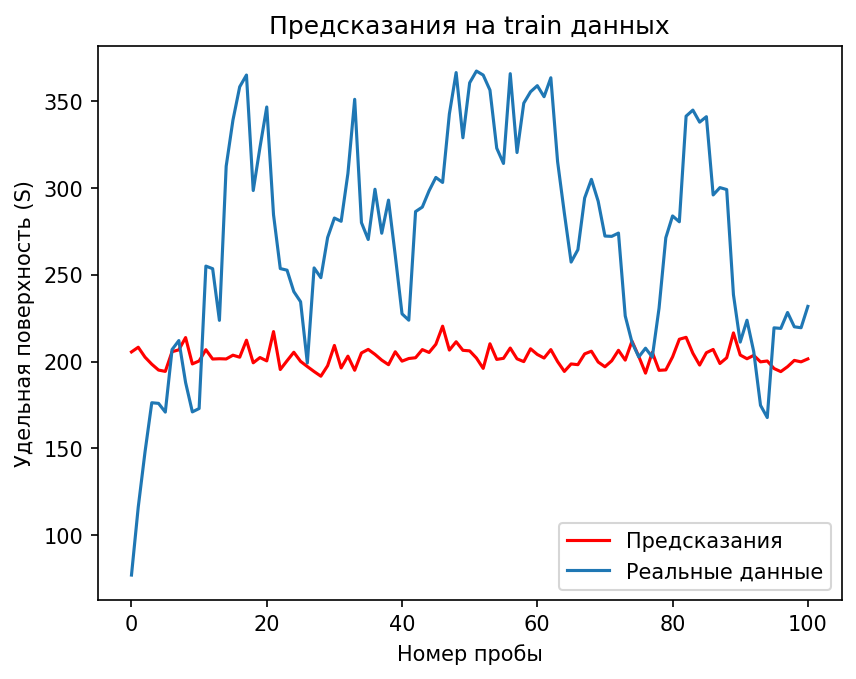
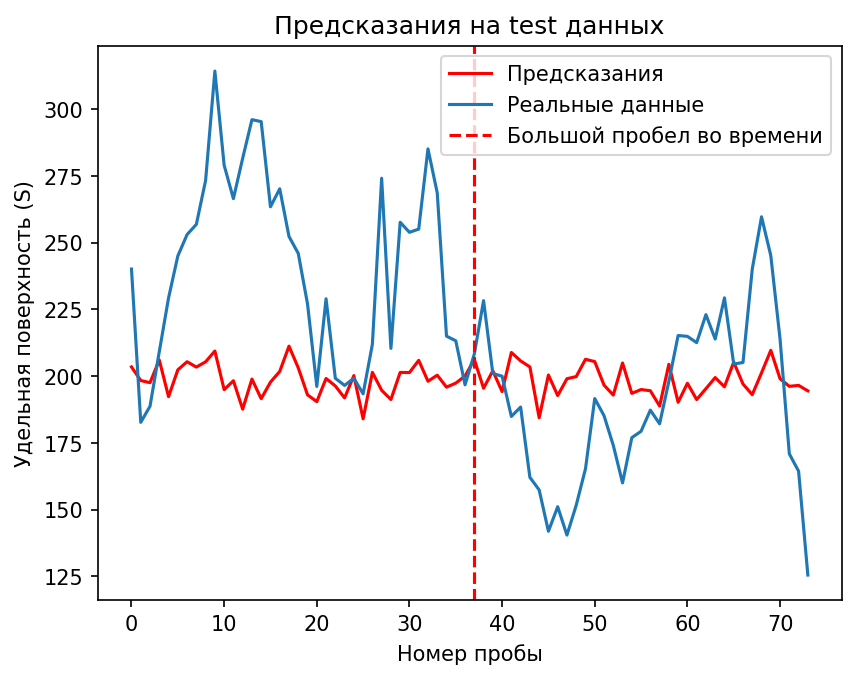

In [15]:
pinn = PINN_v3(k=0.00189)

optimizer = optim.AdamW(pinn.parameters(), lr=0.001)
history = []
h_pde = []
h_bc1 = []
h_bc2 = []
test_loss = []

print('НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ')
for epoch in range(1_000):
    pinn.train()
    optimizer.zero_grad()

    loss, loss_pde_S, loss_pde_M, loss_bc1, loss_bc2, loss_ic = pinn_loss(
        pinn,
        torch.tensor(data["t_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_pde_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_pde_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc1_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc1_train"], dtype=torch.float32).reshape(-1, 1), 

        torch.tensor(data["t_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_bc2_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_bc2_train"], dtype=torch.float32).reshape(-1, 1),

        torch.tensor(data["t_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["z_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["v_ic_train"], dtype=torch.float32).reshape(-1, 1),
        torch.tensor(data["S_ic_train"], dtype=torch.float32).reshape(-1, 1),
        lambda_pde_S=1.0,
        lambda_pde_M=1.0,
        lambda_bc1=0.0, 
        lambda_bc2=0.0,
        lambda_ic=0.0,
    )

    loss.backward()
    optimizer.step()
    history.append(loss.item())
    h_pde.append(loss_pde_S)
    h_bc1.append(loss_bc1)
    h_bc2.append(loss_bc2)

    if epoch % 100 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.3f} | k = {pinn.k:.5f}")
    
    if epoch % 1000 == 0:
        print(f'Loss PDE: {loss_pde_S:.3f} | Loss BC1: {loss_bc1:.3f} | Loss BC2: {loss_bc2:.3f}')
        print('-' * 50)
    
    pred_S, pred_M = pinn(
        torch.tensor(data['t_bc2_test'], dtype=torch.float32),
        torch.tensor(data['z_bc2_test'], dtype=torch.float32),
        torch.tensor(data['v_bc2_test'], dtype=torch.float32),
        )
    pred_S = pred_S.detach()
    pred_M = pred_M.detach()
    test_loss.append(F.mse_loss(torch.tensor(data["S_bc2_test"], dtype=torch.float32).reshape(-1, 1), pred_S))


НАЧАЛО ОБУЧЕНИЯ PINN НА РЕАЛЬНЫХ ДАННЫХ
Epoch 0 | Loss: 1539.446 | k = 0.00189
Loss PDE: 1539.446 | Loss BC1: 1.403 | Loss BC2: 65704.633
--------------------------------------------------


KeyboardInterrupt: 

In [16]:
plt.figure(dpi=150)
plt.plot(train_pred.numpy(), c='r', label='Предсказания')
plt.scatter(data['v_bc2_train'],
        data["S_bc2_train"],  label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Время")
plt.legend()
plt.show()

NameError: name 'train_pred' is not defined

<Figure size 960x720 with 0 Axes>

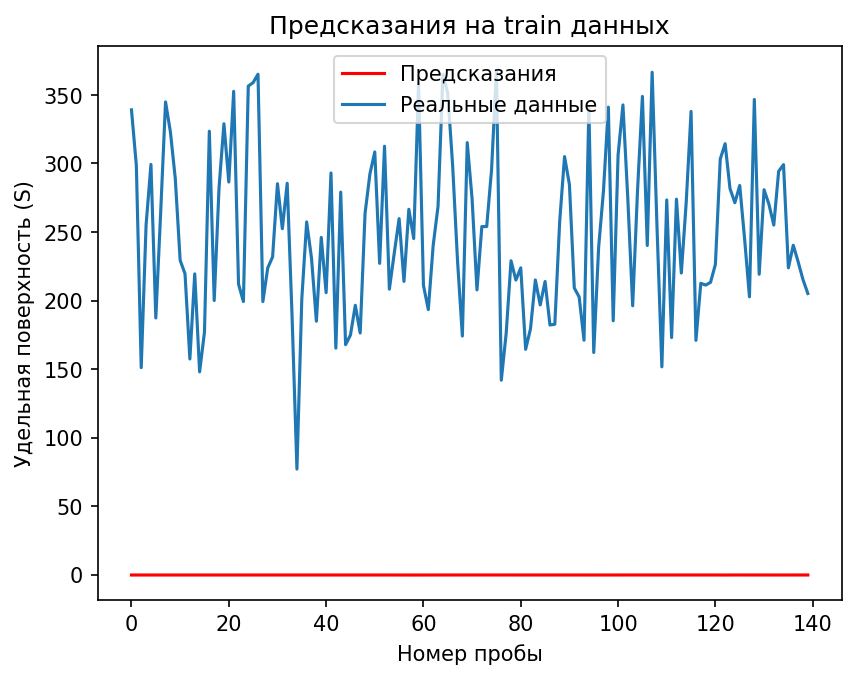

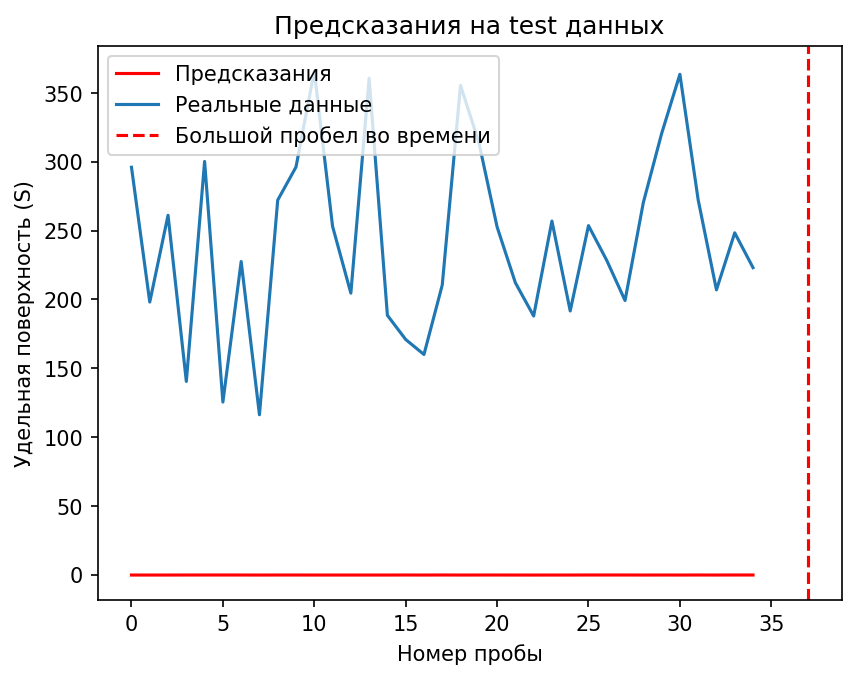

In [18]:
train_pred, _ = pinn(
        torch.tensor(data['t_bc2_train'], dtype=torch.float32),
        torch.tensor(data['z_bc2_train'], dtype=torch.float32),
        torch.tensor(data['v_bc2_train'], dtype=torch.float32),
        )
train_pred = train_pred.detach()

test_pred, _ = pinn(
        torch.tensor(data['t_bc2_test'], dtype=torch.float32),
        torch.tensor(data['z_bc2_test'], dtype=torch.float32),
        torch.tensor(data['v_bc2_test'], dtype=torch.float32),
        )
test_pred = test_pred.detach()

plt.figure(dpi=150)
plt.plot(train_pred.numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_train"], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.legend()
plt.show()

plt.figure(dpi=150)
plt.plot(test_pred.numpy(), c='r', label='Предсказания')
plt.plot(
        data["S_bc2_test"],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Номер пробы")
plt.axvline(x=37, linestyle='--', c='r', label='Большой пробел во времени')
plt.legend()
plt.show()

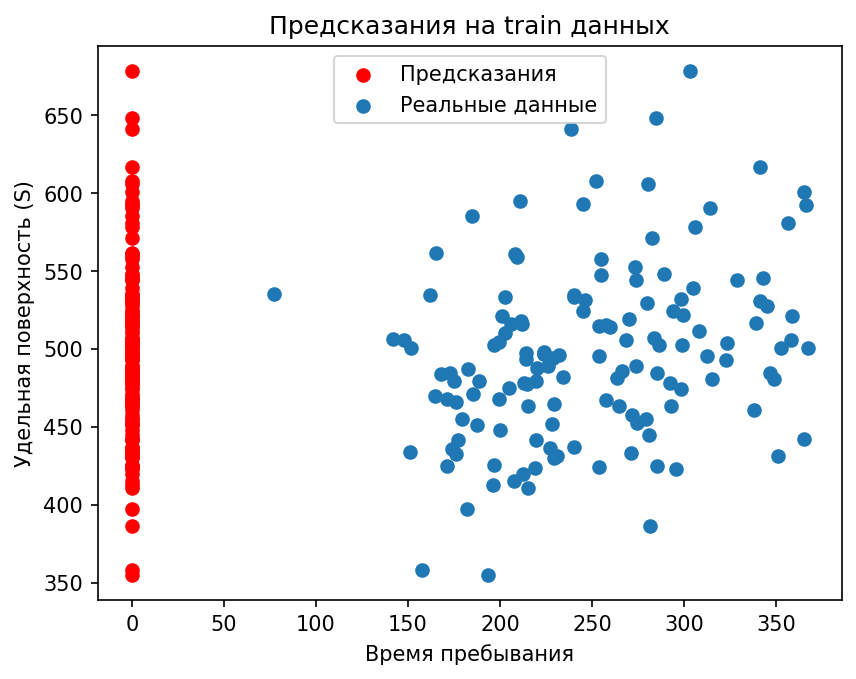

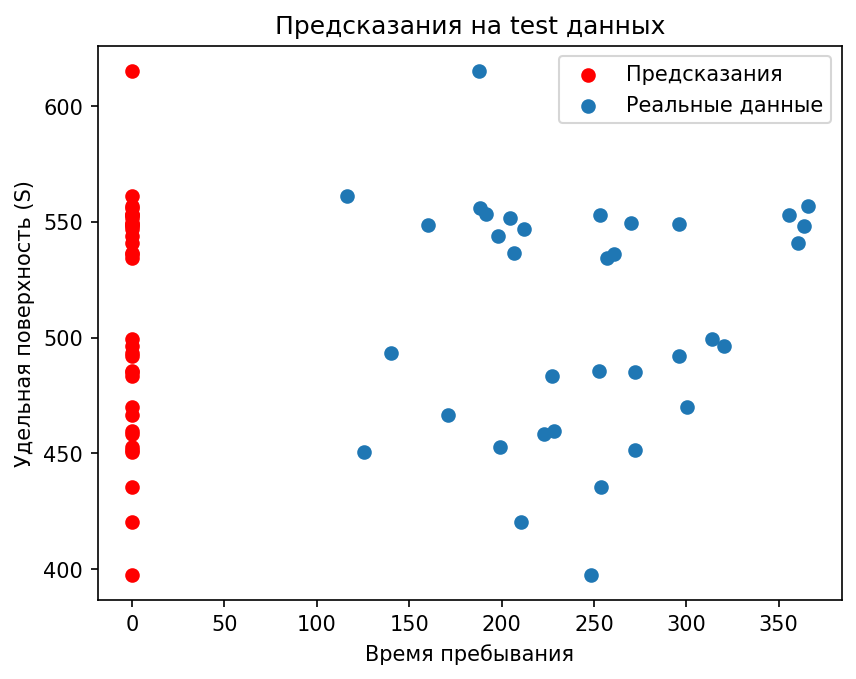

In [19]:
train_pred, _ = pinn(
        torch.tensor(data['t_bc2_train'], dtype=torch.float32),
        torch.tensor(data['z_bc2_train'], dtype=torch.float32),
        torch.tensor(data['v_bc2_train'], dtype=torch.float32),
        )
train_pred = train_pred.detach()

test_pred, _ = pinn(
        torch.tensor(data['t_bc2_test'], dtype=torch.float32),
        torch.tensor(data['z_bc2_test'], dtype=torch.float32),
        torch.tensor(data['v_bc2_test'], dtype=torch.float32),
        )
test_pred = test_pred.detach()

plt.figure(dpi=150)
plt.scatter(train_pred.numpy(), data['t_bc2_train'], c='r', label='Предсказания')
plt.scatter(
        data["S_bc2_train"], data['t_bc2_train'], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Время пребывания")
plt.legend()
plt.show()

plt.figure(dpi=150)
plt.scatter(test_pred.numpy(), data['t_bc2_test'],  c='r', label='Предсказания')
plt.scatter(
        data["S_bc2_test"],data['t_bc2_test'],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Время пребывания")
# plt.axvline(x=37, linestyle='--', c='r', label='Большой пробел во времени')
plt.legend()
plt.show()

In [ ]:
train_pred, _ = pinn(
        torch.tensor(data['t_bc2_train'], dtype=torch.float32),
        torch.tensor(data['z_bc2_train'], dtype=torch.float32),
        torch.tensor(data['v_bc2_train'], dtype=torch.float32),
        )
train_pred = train_pred.detach()

test_pred, _ = pinn(
        torch.tensor(data['t_bc2_test'], dtype=torch.float32),
        torch.tensor(data['z_bc2_test'], dtype=torch.float32),
        torch.tensor(data['v_bc2_test'], dtype=torch.float32),
        )
test_pred = test_pred.detach()

plt.figure(dpi=150)
plt.scatter(train_pred.numpy(), data['v'], c='r', label='Предсказания')
plt.scatter(
        data["S_bc2_train"], data['t_bc2_train'], label='Реальные данные'
        )
plt.title("Предсказания на train данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Время пребывания")
plt.legend()
plt.show()

plt.figure(dpi=150)
plt.scatter(test_pred.numpy(), data['t_bc2_test'],  c='r', label='Предсказания')
plt.scatter(
        data["S_bc2_test"],data['t_bc2_test'],  label='Реальные данные'
        )
plt.title("Предсказания на test данных")
plt.ylabel("Удельная поверхность (S)")
plt.xlabel("Время пребывания")
# plt.axvline(x=37, linestyle='--', c='r', label='Большой пробел во времени')
plt.legend()
plt.show()